# Influence de la masse molaire sur les relaxations moléculaires d’un polyméthacrylate de méthyle (PMMA) #

## Analyse des courbes obtenues par DMA ##


In [96]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model


In [97]:
PMMA80   = pd.read_csv('PMMA80.csv',   sep=';', decimal=',')
PMMA120  = pd.read_csv('PMMA120.csv',  sep=';', decimal=',')
PMMA3500 = pd.read_csv('PMMA3500.csv', sep=';', decimal=',')

# On applique un lissage par moyenne glissante pour réduire le bruit dans les données
PMMA80 = PMMA80.rolling(window=5).mean().dropna()
PMMA120 = PMMA120.rolling(window=5).mean().dropna()
PMMA3500 = PMMA3500.rolling(window=5).mean().dropna()

In [98]:
print(PMMA80.columns)

Index(['Temp(C)', 'Modulus 10', 'Modulus 0,1', 'Modulus 1', 'Loss Modulus10',
       'Loss Modulus 0,1', 'Loss Modulus 1', 'Tan Delta10,', 'Tan Delta,1',
       'Tan Delta1,'],
      dtype='str')


### Transitions vitreuses ###


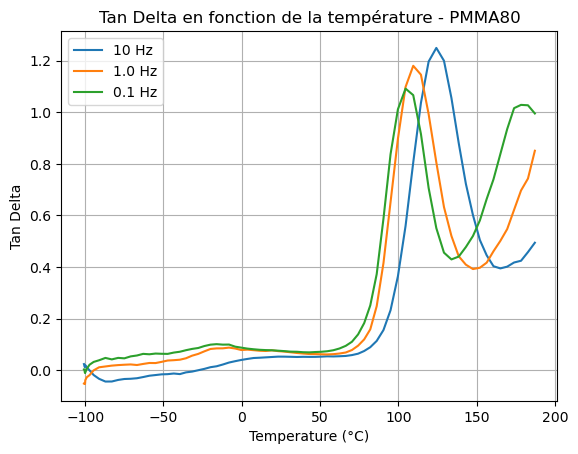

A 10 HZ, la transition vitreuse se situe à 124.16 °C
A 1.0 HZ, la transition vitreuse se situe à 109.42 °C
A 0.1 HZ, la transition vitreuse se situe à 104.52000000000001 °C


In [99]:
# PMMA80----------------------------------------------------------

plt.plot(PMMA80['Temp(C)'], PMMA80['Tan Delta10,'], label='10 Hz')
plt.plot(PMMA80['Temp(C)'], PMMA80['Tan Delta1,'], label='1.0 Hz')
plt.plot(PMMA80['Temp(C)'], PMMA80['Tan Delta,1'], label='0.1 Hz')

plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.legend()
plt.title("Tan Delta en fonction de la température - PMMA80")
plt.grid()
plt.show()

print(f"A 10 HZ, la transition vitreuse se situe à {PMMA80['Temp(C)'][PMMA80['Tan Delta10,'].idxmax()]} °C")
print(f"A 1.0 HZ, la transition vitreuse se situe à {PMMA80['Temp(C)'][PMMA80['Tan Delta1,'].idxmax()]} °C")
print(f"A 0.1 HZ, la transition vitreuse se situe à {PMMA80['Temp(C)'][PMMA80['Tan Delta,1'].idxmax()]} °C")

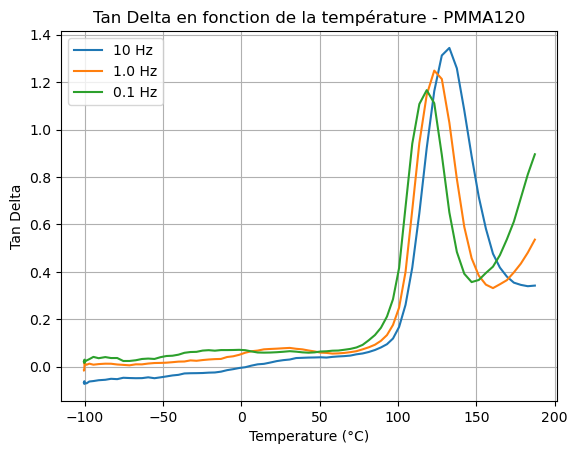

A 10 HZ, la transition vitreuse se situe à 132.78000000000003 °C
A 1.0 HZ, la transition vitreuse se situe à 123.14000000000001 °C
A 0.1 HZ, la transition vitreuse se situe à 118.32000000000001 °C


In [100]:
# PMMA120----------------------------------------------------------

plt.plot(PMMA120['Temp(C)'], PMMA120['Tan Delta10,'], label='10 Hz')
plt.plot(PMMA120['Temp(C)'], PMMA120['Tan Delta1,'], label='1.0 Hz')
plt.plot(PMMA120['Temp(C)'], PMMA120['Tan Delta,1'], label='0.1 Hz')

plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.legend()
plt.title("Tan Delta en fonction de la température - PMMA120")
plt.grid()
plt.show()

print(f"A 10 HZ, la transition vitreuse se situe à {PMMA120['Temp(C)'][PMMA120['Tan Delta10,'].idxmax()]} °C")
print(f"A 1.0 HZ, la transition vitreuse se situe à {PMMA120['Temp(C)'][PMMA120['Tan Delta1,'].idxmax()]} °C")
print(f"A 0.1 HZ, la transition vitreuse se situe à {PMMA120['Temp(C)'][PMMA120['Tan Delta,1'].idxmax()]} °C")

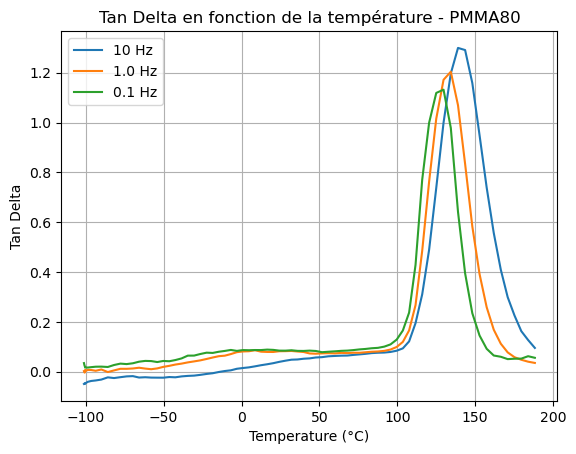

A 10 HZ, la transition vitreuse se situe à 138.94 °C
A 1.0 HZ, la transition vitreuse se situe à 134.32 °C
A 0.1 HZ, la transition vitreuse se situe à 129.66 °C


In [101]:
# PMMA3500----------------------------------------------------------

plt.plot(PMMA3500['Temp(C)'], PMMA3500['Tan Delta10,'], label='10 Hz')
plt.plot(PMMA3500['Temp(C)'], PMMA3500['Tan Delta1,'], label='1.0 Hz')
plt.plot(PMMA3500['Temp(C)'], PMMA3500['Tan Delta,1'], label='0.1 Hz')

plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.legend()
plt.title("Tan Delta en fonction de la température - PMMA80")
plt.grid()
plt.show()

print(f"A 10 HZ, la transition vitreuse se situe à {PMMA3500['Temp(C)'][PMMA3500['Tan Delta10,'].idxmax()]} °C")
print(f"A 1.0 HZ, la transition vitreuse se situe à {PMMA3500['Temp(C)'][PMMA3500['Tan Delta1,'].idxmax()]} °C")
print(f"A 0.1 HZ, la transition vitreuse se situe à {PMMA3500['Temp(C)'][PMMA3500['Tan Delta,1'].idxmax()]} °C")

### Calcul des énergies d'activation ###

#### Transition vitreuse  ####

In [102]:
Ea80 = [PMMA80['Temp(C)'][PMMA80['Tan Delta10,'].idxmax()], 
                PMMA80['Temp(C)'][PMMA80['Tan Delta1,'].idxmax()], 
                PMMA80['Temp(C)'][PMMA80['Tan Delta,1'].idxmax()]]
Ea120 = [PMMA120['Temp(C)'][PMMA120['Tan Delta10,'].idxmax()],
                PMMA120['Temp(C)'][PMMA120['Tan Delta1,'].idxmax()],
                PMMA120['Temp(C)'][PMMA120['Tan Delta,1'].idxmax()]]
Ea3500 = [PMMA3500['Temp(C)'][PMMA3500['Tan Delta10,'].idxmax()],
                PMMA3500['Temp(C)'][PMMA3500['Tan Delta1,'].idxmax()],
                PMMA3500['Temp(C)'][PMMA3500['Tan Delta,1'].idxmax()]]
freq = [10, 1, 0.1]
R = 8.314

In [103]:
#PMMA80----------------------------------------------------------------------
X=[]
Y = []
for i in range(3):
    X.append((1/R)*((1/(Ea80[i]+273.15))-(1/(Ea80[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation pour PMMA80 : {lm.coef_*1e-3} kJ/mol")


Energie d'activation pour PMMA80 : [[271.51220982]] kJ/mol


In [104]:
#PMMA120----------------------------------------------------------------------
X=[]
Y = []
for i in range(3):
    X.append((1/R)*((1/(Ea120[i]+273.15))-(1/(Ea120[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation pour PMMA120 : {lm.coef_*1e-3} kJ/mol")

Energie d'activation pour PMMA120 : [[407.11563383]] kJ/mol


In [105]:
#PMMA3500----------------------------------------------------------------------
X=[]
Y = []
for i in range(3):
    X.append((1/R)*((1/(Ea3500[i]+273.15))-(1/(Ea3500[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation pour PMMA3500 : {lm.coef_*1e-3} kJ/mol")

Energie d'activation pour PMMA3500 : [[684.80098704]] kJ/mol


#### Transition beta ####

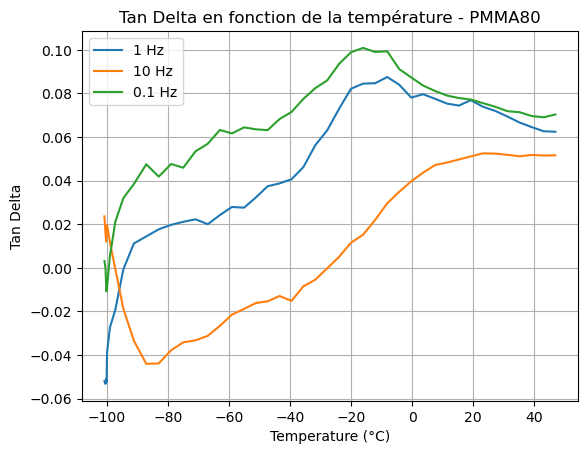

In [106]:
#PMMA80----------------------------------------------------------------------
# Il est clair d'après les premiers graphiques que les transitions beta s'effectuent
# dans l'intervalle de température de -100°C à 40°C, on se concentre donc sur cette plage
# pour mieux voir les variatons de tan delta. 
plt.plot(PMMA80['Temp(C)'][:45], PMMA80['Tan Delta1,'][:45], label='1 Hz')
plt.plot(PMMA80['Temp(C)'][:45], PMMA80['Tan Delta10,'][:45], label='10 Hz')
plt.plot(PMMA80['Temp(C)'][:45], PMMA80['Tan Delta,1'][:45], label='0.1 Hz')
plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.title("Tan Delta en fonction de la température - PMMA80")
plt.grid()
plt.legend()
plt.show()


La courbe à 10 Hz ne présente pas de variariation explicite, on va donc la négliger pour la suite. La transition beta a clairement l'air de s'effectuer aux alentours de -20°C. Utilisons l'annulation de la dérivée pour déterminer précisément les températures de transition. 

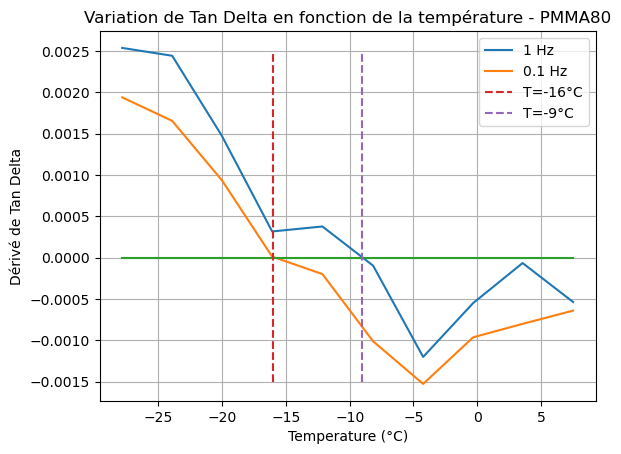

In [107]:
plt.plot(PMMA80['Temp(C)'][25:35], np.gradient(PMMA80['Tan Delta1,'][25:35],PMMA80['Temp(C)'][25:35]), label='1 Hz')
plt.plot(PMMA80['Temp(C)'][25:35], np.gradient(PMMA80['Tan Delta,1'][25:35],PMMA80['Temp(C)'][25:35]), label='0.1 Hz')
plt.plot(PMMA80['Temp(C)'][25:35],[0 for i in range(len(PMMA80['Temp(C)'][25:35]))])
plt.plot([-16 for i in range(len(PMMA80['Temp(C)'][25:35]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA80['Temp(C)'][25:35]))], '--', label='T=-16°C')
plt.plot([-9 for i in range(len(PMMA80['Temp(C)'][25:35]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA80['Temp(C)'][25:35]))], '--', label='T=-9°C')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dérivé de Tan Delta')
plt.title("Variation de Tan Delta en fonction de la température - PMMA80")
plt.grid()
plt.legend()
plt.show()

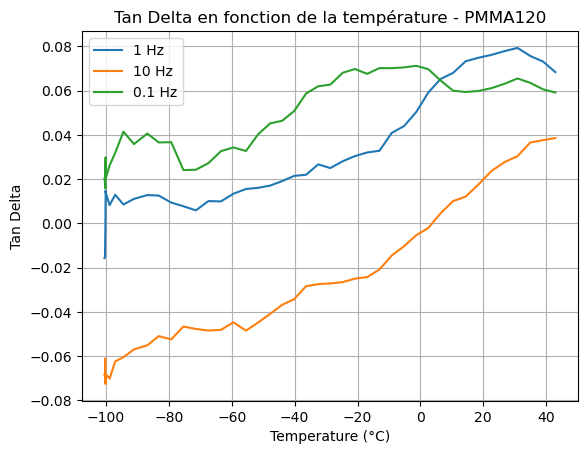

In [108]:
#PMMA120----------------------------------------------------------------------
# Il est clair d'après les premiers graphiques que les transitions beta s'effectuent
# dans l'intervalle de température de -100°C à 40°C, on se concentre donc sur cette plage
# pour mieux voir les variatons de tan delta. 
plt.plot(PMMA120['Temp(C)'][:45], PMMA120['Tan Delta1,'][:45], label='1 Hz')
plt.plot(PMMA120['Temp(C)'][:45], PMMA120['Tan Delta10,'][:45], label='10 Hz')
plt.plot(PMMA120['Temp(C)'][:45], PMMA120['Tan Delta,1'][:45], label='0.1 Hz')
plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.title("Tan Delta en fonction de la température - PMMA120")
plt.grid()
plt.legend()
plt.show()

Par lecture graphique on voit que la transition s'effectue aux alentours de -10°C pour 0.1 Hz et 20°C pour 1 Hz. Encore une fois, on néglige 10 Hz.

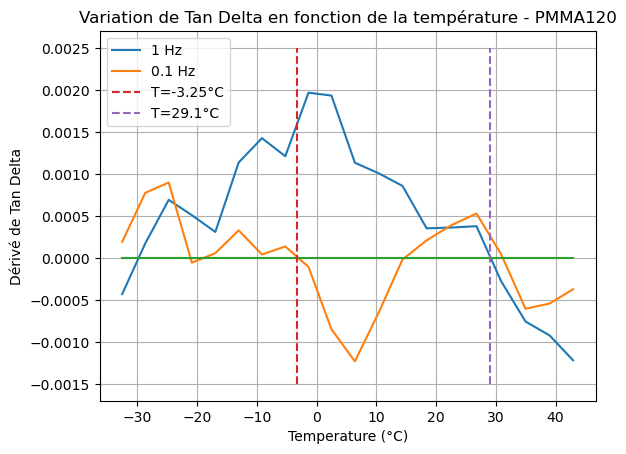

In [109]:
plt.plot(PMMA120['Temp(C)'][25:45], np.gradient(PMMA120['Tan Delta1,'][25:45],PMMA120['Temp(C)'][25:45]), label='1 Hz')
plt.plot(PMMA120['Temp(C)'][25:45], np.gradient(PMMA120['Tan Delta,1'][25:45],PMMA120['Temp(C)'][25:45]), label='0.1 Hz')
plt.plot(PMMA120['Temp(C)'][25:45],[0 for i in range(len(PMMA120['Temp(C)'][25:45]))])
plt.plot([-3.25 for i in range(len(PMMA120['Temp(C)'][25:45]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA120['Temp(C)'][25:45]))], '--', label='T=-3.25°C')
plt.plot([29.1 for i in range(len(PMMA120['Temp(C)'][25:45]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA120['Temp(C)'][25:45]))], '--', label='T=29.1°C')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dérivé de Tan Delta')
plt.title("Variation de Tan Delta en fonction de la température - PMMA120")
plt.grid()
plt.legend()
plt.show()

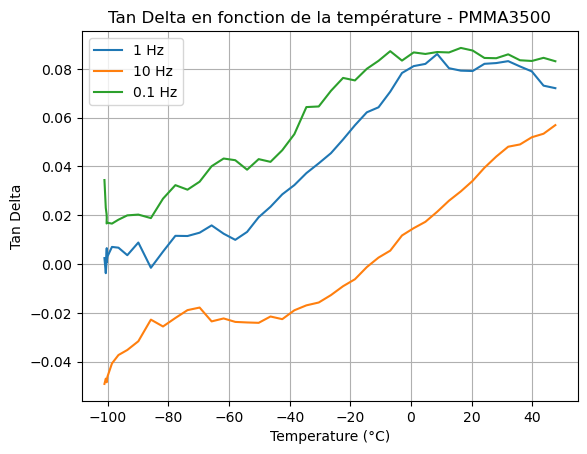

In [110]:
#PMMA3500----------------------------------------------------------------------
# Il est clair d'après les premiers graphiques que les transitions beta s'effectuent
# dans l'intervalle de température de -100°C à 40°C, on se concentre donc sur cette plage
# pour mieux voir les variatons de tan delta. 
plt.plot(PMMA3500['Temp(C)'][:45], PMMA3500['Tan Delta1,'][:45], label='1 Hz')
plt.plot(PMMA3500['Temp(C)'][:45], PMMA3500['Tan Delta10,'][:45], label='10 Hz')
plt.plot(PMMA3500['Temp(C)'][:45], PMMA3500['Tan Delta,1'][:45], label='0.1 Hz')
plt.xlabel('Temperature (°C)')
plt.ylabel('Tan Delta')
plt.title("Tan Delta en fonction de la température - PMMA3500")
plt.grid()
plt.legend()
plt.show()

Par lecture graphique on voit que la transition s'effectue entre 0 et 20°C. Encore une fois, on néglige 10 Hz.

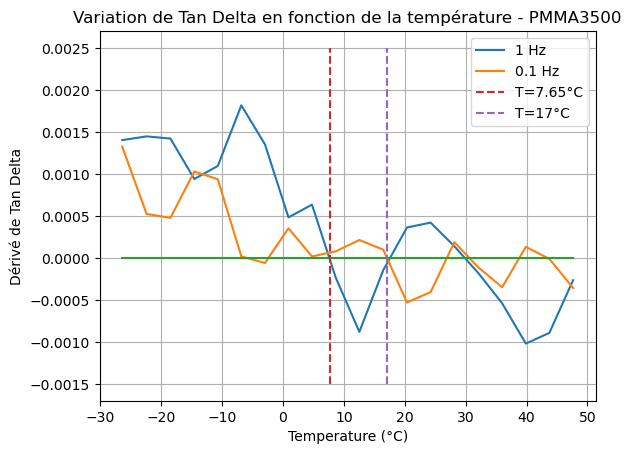

In [111]:
plt.plot(PMMA3500['Temp(C)'][25:45], np.gradient(PMMA3500['Tan Delta1,'][25:45],PMMA3500['Temp(C)'][25:45]), label='1 Hz')
plt.plot(PMMA3500['Temp(C)'][25:45], np.gradient(PMMA3500['Tan Delta,1'][25:45],PMMA3500['Temp(C)'][25:45]), label='0.1 Hz')
plt.plot(PMMA3500['Temp(C)'][25:45],[0 for i in range(len(PMMA3500['Temp(C)'][25:45]))])
plt.plot([7.65 for i in range(len(PMMA3500['Temp(C)'][25:45]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA3500['Temp(C)'][25:45]))], '--', label='T=7.65°C')
plt.plot([17 for i in range(len(PMMA3500['Temp(C)'][25:45]))], 
         [x for x in np.linspace(-0.0015, 0.0025, len(PMMA3500['Temp(C)'][25:45]))], '--', label='T=17°C')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dérivé de Tan Delta')
plt.title("Variation de Tan Delta en fonction de la température - PMMA3500")
plt.grid()
plt.legend()
plt.show()

In [112]:
Ea_beta80 = [-9,-16]
Ea_beta120 = [29.1, -3.25]
Ea_beta3500 = [17,7.65]
freq = [1, 0.1]

In [113]:
#PMMA80----------------------------------------------------------------------
X=[]
Y = []
for i in range(2):
    X.append((1/R)*((1/(Ea_beta80[i]+273.15))-(1/(Ea_beta80[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation de la transition beta pour PMMA80 : {lm.coef_*1e-3} kJ/mol")

Energie d'activation de la transition beta pour PMMA80 : [[185.76539379]] kJ/mol


In [114]:
#PMMA120----------------------------------------------------------------------
X=[]
Y = []
for i in range(2):
    X.append((1/R)*((1/(Ea_beta120[i]+273.15))-(1/(Ea_beta120[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation de la transition beta pour PMMA120 : {lm.coef_*1e-3} kJ/mol")

Energie d'activation de la transition beta pour PMMA120 : [[48.27481498]] kJ/mol


In [115]:
#PMMA3500----------------------------------------------------------------------
X=[]
Y = []
for i in range(2):
    X.append((1/R)*((1/(Ea_beta3500[i]+273.15))-(1/(Ea_beta3500[0]+273.15))))
    Y.append(np.log(freq[0]/freq[i]))
lm = linear_model.LinearRegression()
X = np.array(X).reshape(-1, 1)
Y = np.array(Y).reshape(-1, 1)
lm.fit(X, Y)
print(f"Energie d'activation de la transition beta pour PMMA3500 : {lm.coef_*1e-3} kJ/mol")

Energie d'activation de la transition beta pour PMMA3500 : [[166.81449166]] kJ/mol
